# 13 - 1D CNN Autoencoder (ESA/Kaggle-tuned)

Symmetric 1D-CNN autoencoder. Encoder: Conv1D + MaxPool1D halves the time
axis twice (100 → 50 → 25) and compresses to 8 channels at the bottleneck.
Decoder mirrors with UpSampling1D and a final linear Conv1D for reconstruction.

**Changes vs the previous NB 13 run:**
- Threshold tuned on **`corrected_event_f05`** (ESA), not event_f05 — previous run
  reported Event F0.5=0.0775 / ESA F0.5=0.0762, very low.
- Uses the **Kaggle 80/20 split** (`data/processed/kaggle/`, `SPLIT_IDX=11_782_656`)
  — directly comparable to NB 04.
- Kaggle **submission cell** at the end (`submissions/13_cnn_ae.parquet`).
- Model save includes timestamp.

Preserved: architecture (32k params), random 50k fit, per-window z-norm adapter,
`topk=5` scoring.

**Inputs:** `data/processed/kaggle/*`
**Outputs:** `models/cnn_ae_<timestamp>.keras`, `submissions/13_cnn_ae.parquet`


## 0 - Setup & Imports

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, json, time, os, gc
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sentinel.ml_logic.scorer import score_windows
from sentinel.ml_logic.data   import find_anomaly_segments
from sentinel.params import (
    FIT_SIZE, RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)

tf.keras.utils.set_random_seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR   = Path('../data/processed/kaggle')
MODELS_DIR      = Path('../models')
SUBMISSIONS_DIR = Path('../kaggle/submissions')
MODELS_DIR.mkdir(exist_ok=True)
SUBMISSIONS_DIR.mkdir(exist_ok=True)

print(f'TF {tf.__version__}   GPUs: {tf.config.list_physical_devices("GPU")}')
print(f'FIT_SIZE = {FIT_SIZE!r}')


TF 2.16.2   GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
FIT_SIZE = 50000


---
## 1 - Load Data (Kaggle 80/20 split)

In [2]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

SPLIT_IDX = cfg['split_idx']      # 11_782_656
WIN       = cfg['window_size']    # 100
N_FEAT    = cfg['n_features']     # 58
assert WIN == WINDOW_SIZE

print('Loading arrays …')
t0 = time.time()
X_train_nom = np.load(PROCESSED_DIR / 'X_train_nom.npy')
X_all       = np.load(PROCESSED_DIR / 'train_full_scaled.npy')
y_all       = np.load(PROCESSED_DIR / 'y_train_row.npy')
X_test      = np.load(PROCESSED_DIR / 'test_scaled.npy')
test_ids    = np.load(PROCESSED_DIR / 'test_ids.npy')
print(f'  loaded in {time.time()-t0:.1f}s')

X_val = X_all[SPLIT_IDX:]
y_val = y_all[SPLIT_IDX:]
del X_all, y_all; gc.collect()

val_segments = find_anomaly_segments(y_val)
n_events     = len(val_segments)
n_nom_val    = int((y_val == 0).sum())
nom_mask_val = (y_val == 0)

print(f'X_train_nom       : {X_train_nom.shape}')
print(f'X_val             : {X_val.shape}   ({int(y_val.sum()):,} anomalous rows)')
print(f'X_test (Kaggle)   : {X_test.shape}')
print(f'Val anomaly events: {n_events}')


Loading arrays …
  loaded in 3.0s
X_train_nom       : (105487, 100, 58)
X_val             : (2945665, 58)   (310,175 anomalous rows)
X_test (Kaggle)   : (521280, 58)
Val anomaly events: 38


---
## 2 - Build CNN-AE

Unchanged architecture from the previous NB 13 (Conv1D 32→16→8 encoder with
MaxPool, Conv1D 16→32→58 decoder with UpSampling1D). Per-window z-normalisation
for drift robustness.

In [3]:
def build_cnn_ae(window_size, n_channels):
    inputs = layers.Input(shape=(window_size, n_channels))
    # Encoder: 100 → 50 → 25
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(16, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D( 8, 3, activation='relu', padding='same')(x)   # bottleneck
    # Decoder: 25 → 50 → 100
    x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    outputs = layers.Conv1D(n_channels, 7, activation='linear', padding='same')(x)
    m = Model(inputs, outputs, name='cnn_ae')
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m


def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)


model = build_cnn_ae(WIN, N_FEAT)
model.summary()


Model: "cnn_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 58)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 32)        │        13,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 16)         │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 25, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 58)        │        13,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,034 (125.13 KB)

 Trainable params: 32,034 (125.13 KB)

 Non-trainable params: 0 (0.00 B)

---
## 3 - Train on random 50k nominal windows

In [4]:
if FIT_SIZE is not None and FIT_SIZE < len(X_train_nom):
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X_train_nom), size=FIT_SIZE, replace=False)
    X_fit_raw = X_train_nom[idx]
    print(f'Training on {len(X_fit_raw):,} randomly sampled windows (FIT_SIZE={FIT_SIZE:,})')
else:
    X_fit_raw = X_train_nom
    print(f'Training on all {len(X_fit_raw):,} nominal windows')

X_fit = zscore_window(X_fit_raw)
del X_fit_raw, X_train_nom; gc.collect()

EPOCHS     = 50
BATCH_SIZE = 256

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
]

t0 = time.time()
history = model.fit(
    X_fit, X_fit,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=2, shuffle=True,
)
print(f'Trained in {(time.time()-t0)/60:.1f} min  ({len(history.history["loss"])} epochs)')


Training on 50,000 randomly sampled windows (FIT_SIZE=50,000)
Epoch 1/50
176/176 - 24s - 135ms/step - loss: 0.8216 - val_loss: 0.7762 - learning_rate: 0.0010
Epoch 2/50
176/176 - 19s - 107ms/step - loss: 0.7565 - val_loss: 0.7421 - learning_rate: 0.0010
Epoch 3/50
176/176 - 18s - 104ms/step - loss: 0.7354 - val_loss: 0.7292 - learning_rate: 0.0010
Epoch 4/50
176/176 - 19s - 107ms/step - loss: 0.7244 - val_loss: 0.7195 - learning_rate: 0.0010
Epoch 5/50
176/176 - 19s - 105ms/step - loss: 0.7156 - val_loss: 0.7123 - learning_rate: 0.0010
Epoch 6/50
176/176 - 18s - 103ms/step - loss: 0.7103 - val_loss: 0.7086 - learning_rate: 0.0010
Epoch 7/50
176/176 - 18s - 102ms/step - loss: 0.7071 - val_loss: 0.7056 - learning_rate: 0.0010
Epoch 8/50
176/176 - 18s - 104ms/step - loss: 0.7047 - val_loss: 0.7033 - learning_rate: 0.0010
Epoch 9/50
176/176 - 19s - 106ms/step - loss: 0.7025 - val_loss: 0.7012 - learning_rate: 0.0010
Epoch 10/50
176/176 - 18s - 103ms/step - loss: 0.7004 - val_loss: 0.6992 -

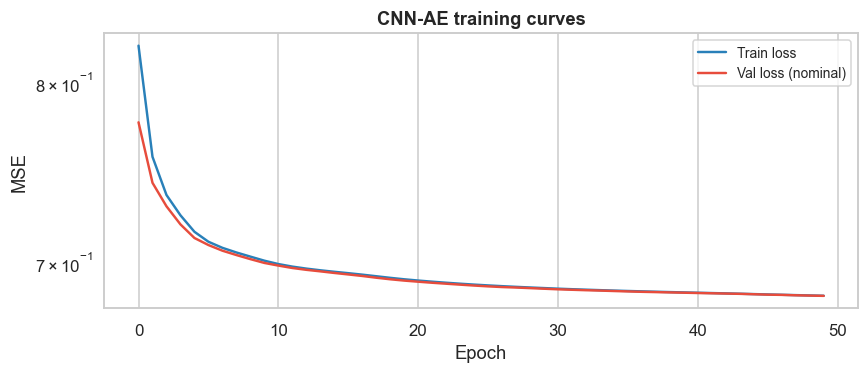

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
h = history.history
ax.plot(h['loss'],     lw=1.6, color=NOMINAL_COLOR, label='Train loss')
ax.plot(h['val_loss'], lw=1.6, color=ANOMALY_COLOR, label='Val loss (nominal)')
ax.set_yscale('log')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('CNN-AE training curves', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()


---
## 4 - Score Val + Kaggle Test

`ZNormAdapter` wraps the model so `score_windows` sees the z-space residual.
`topk=5`: per-window score = mean of the 5 worst-reconstructed channels.

In [7]:
class ZNormAdapter:
    '''Wraps a Keras AE trained on z-normalised windows so score_windows sees
    the z-space residual. Given score_windows computes ((X - predict(X))**2),
    we return pred = X - Xn + Xhat so (X - pred) == (Xn - Xhat).'''
    def __init__(self, model):
        self.model = model
    def predict(self, X, batch_size=256, verbose=0):
        Xn   = zscore_window(X)
        Xhat = self.model.predict(Xn, batch_size=batch_size, verbose=verbose)
        return X - Xn + Xhat


scorer = ZNormAdapter(model)
TOPK   = 5

t0 = time.time()
val_scores = score_windows(scorer, X_val, win=WIN, batch=256, topk=TOPK)
print(f'val_scores  : {val_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{val_scores.min():.4f}, {val_scores.max():.4f}]')

t0 = time.time()
test_scores = score_windows(scorer, X_test, win=WIN, batch=256, topk=TOPK)
print(f'test_scores : {test_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{test_scores.min():.4f}, {test_scores.max():.4f}]')
print(f'  val mean nominal : {val_scores[y_val==0].mean():.4f}')
print(f'  val mean anomaly : {val_scores[y_val==1].mean():.4f}')


val_scores  : (2945665,)   (3.6s)   range [0.9998, 1.2336]
test_scores : (521280,)   (0.8s)   range [0.9997, 1.1687]
  val mean nominal : 1.0442
  val mean anomaly : 1.0462


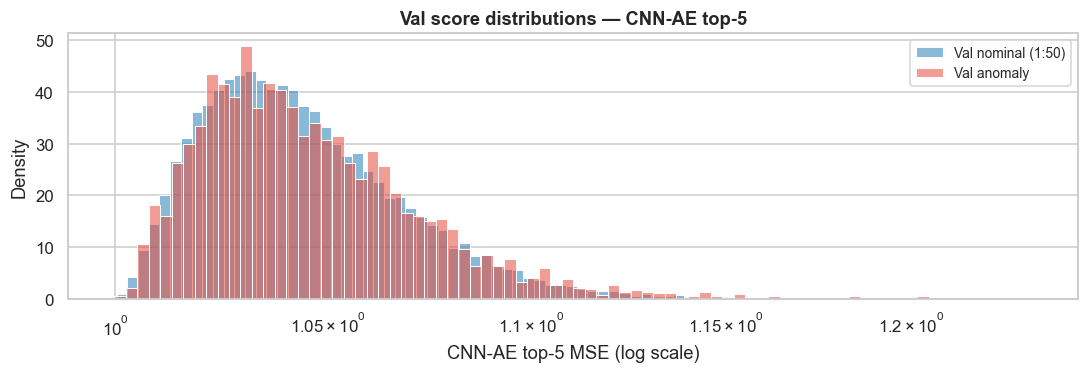

ROC-AUC (row-level): 0.5122


In [8]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(val_scores[y_val == 0][::50], ax=ax, color=NOMINAL_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val nominal (1:50)')
sns.histplot(val_scores[y_val == 1], ax=ax, color=ANOMALY_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val anomaly')
ax.set_xlabel(f'CNN-AE top-{TOPK} MSE (log scale)')
ax.set_ylabel('Density')
ax.set_title(f'Val score distributions — CNN-AE top-{TOPK}', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_val, val_scores)
print(f'ROC-AUC (row-level): {auc:.4f}')


---
## 5 - Threshold Tuning on Corrected Event-Wise F0.5

Same 400-point sweep as NB 04: `Pr_c = Pr_ew × TNR`, logs `fp_pred_events`
and `pos_rate` so segment-merge pathology is visible.

In [9]:
gt_cumsum = np.concatenate([[0], np.cumsum((y_val == 1).astype(np.int32))])
seg_max_scores = np.array(
    [val_scores[s['start']:s['end']+1].max() for s in val_segments],
    dtype=np.float32,
)

thresholds = np.linspace(
    np.percentile(val_scores, 0.5),
    np.percentile(val_scores, 99.9),
    num=400,
)

results = []
for thr in thresholds:
    pred = (val_scores >= thr).astype(np.int8)
    tp = int((seg_max_scores >= thr).sum())
    fn = n_events - tp
    padded = np.concatenate([[0], pred, [0]])
    d      = np.diff(padded)
    starts_pred = np.where(d ==  1)[0]
    ends_pred   = np.where(d == -1)[0] - 1
    fp_pred_ev  = int(((gt_cumsum[ends_pred+1] - gt_cumsum[starts_pred]) == 0).sum()) if len(starts_pred) > 0 else 0
    fp_samples  = int(((val_scores >= thr) & nom_mask_val).sum())
    tnr         = max(0.0, 1.0 - fp_samples / n_nom_val) if n_nom_val > 0 else 1.0
    denom_pr    = tp + fp_pred_ev
    pr_ew       = tp / denom_pr if denom_pr > 0 else 0.0
    precision   = pr_ew * tnr
    recall      = tp / n_events if n_events > 0 else 0.0
    f05         = (1.25 * precision * recall / (0.25 * precision + recall)
                   if (precision + recall) > 0 else 0.0)
    results.append({
        'threshold':float(thr),'f05':f05,'precision':precision,'recall':recall,
        'tp_events':tp,'fn_events':fn,'fp_pred_events':fp_pred_ev,
        'fp_samples':fp_samples,'tnr':tnr,'n_predicted':int(pred.sum()),
        'pos_rate':pred.mean(),
    })

res_df = pd.DataFrame(results)
best   = res_df.loc[res_df['f05'].idxmax()]
print(f'Sweep done ({len(thresholds)} thresholds).\n')
print('=== Best threshold (corrected event-wise F0.5) ===')
for col in ['threshold','f05','precision','recall','tp_events','fn_events',
            'fp_pred_events','fp_samples','tnr','n_predicted','pos_rate']:
    print(f'  {col:<16}: {best[col]}')
print()
print(f'NB 04 reference: F0.5=0.770, 21/38 events, fp_pred_events=0, pos_rate=18.08%')


Sweep done (400 thresholds).

=== Best threshold (corrected event-wise F0.5) ===
  threshold       : 1.1560284502822953
  f05             : 0.18105977856872207
  precision       : 0.19984822556716209
  recall          : 0.13157894736842105
  tp_events       : 5.0
  fn_events       : 33.0
  fp_pred_events  : 20.0
  fp_samples      : 2000.0
  tnr             : 0.9992411278358104
  n_predicted     : 3600.0
  pos_rate        : 0.001222134899929218

NB 04 reference: F0.5=0.770, 21/38 events, fp_pred_events=0, pos_rate=18.08%


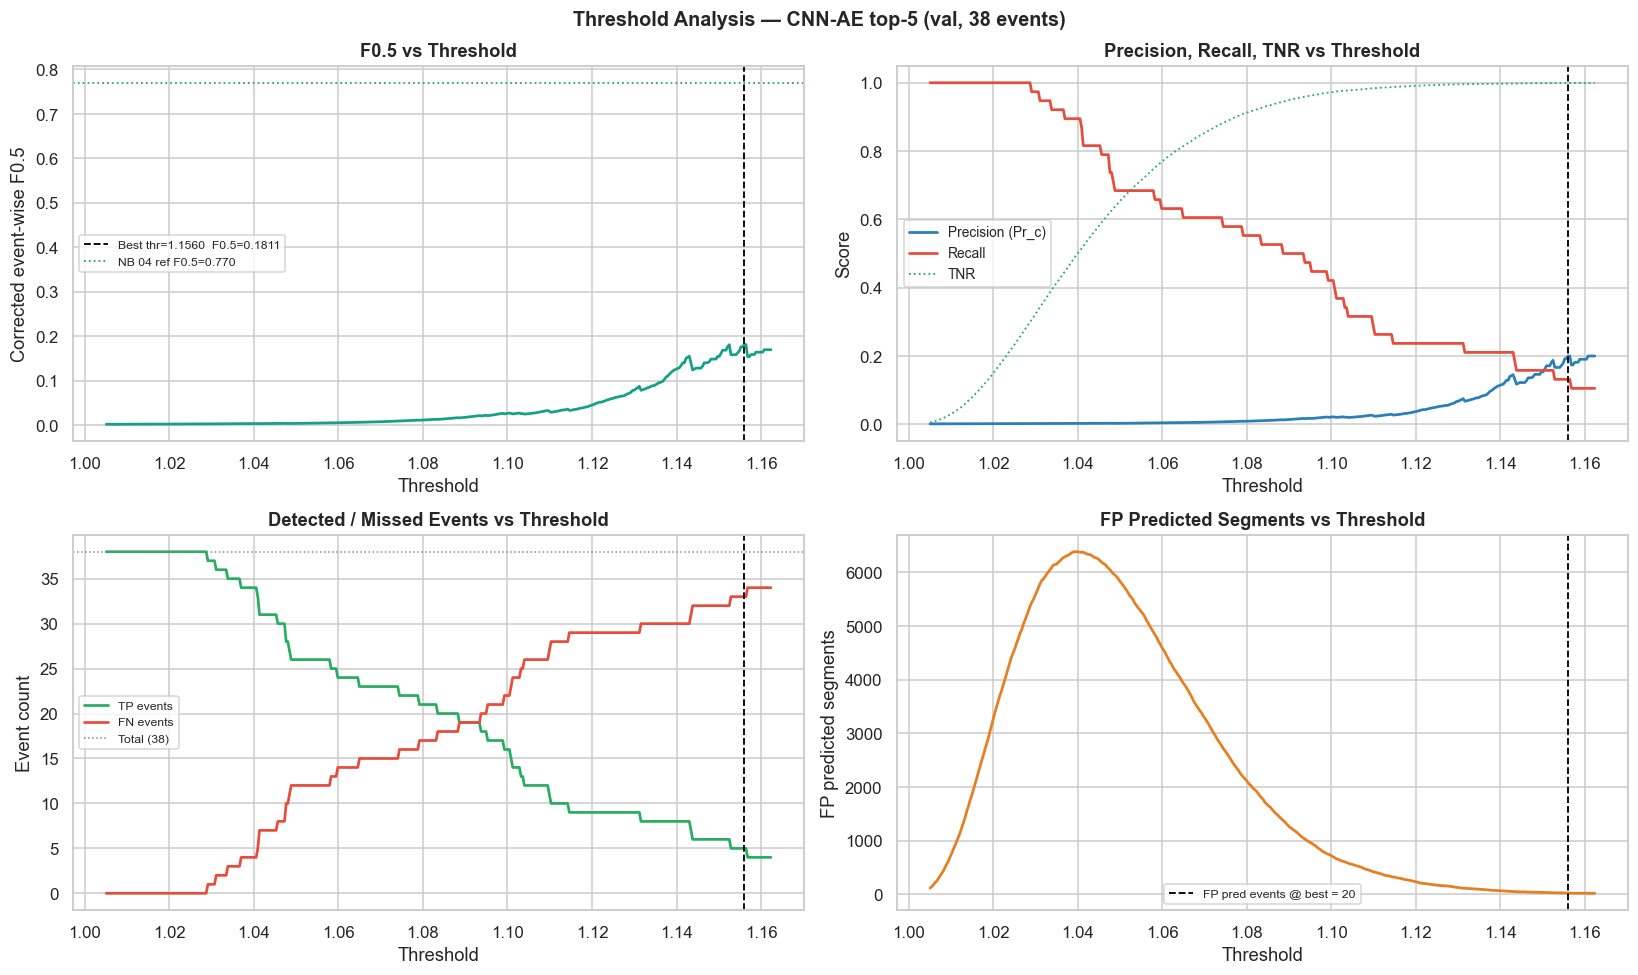

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

ax = axes[0, 0]
ax.plot(res_df['threshold'], res_df['f05'], color='#16a085', lw=1.8)
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2,
           label=f'Best thr={best["threshold"]:.4f}  F0.5={best["f05"]:.4f}')
ax.axhline(0.770, color='#27ae60', ls=':', lw=1.2, label='NB 04 ref F0.5=0.770')
ax.set_xlabel('Threshold'); ax.set_ylabel('Corrected event-wise F0.5')
ax.set_title('F0.5 vs Threshold', fontweight='bold'); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(res_df['threshold'], res_df['precision'], color=NOMINAL_COLOR, lw=1.8, label='Precision (Pr_c)')
ax.plot(res_df['threshold'], res_df['recall'],    color=ANOMALY_COLOR, lw=1.8, label='Recall')
ax.plot(res_df['threshold'], res_df['tnr'],       color='#27ae60',     lw=1.2, ls=':', label='TNR')
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Precision, Recall, TNR vs Threshold', fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(-0.05, 1.05)

ax = axes[1, 0]
ax.plot(res_df['threshold'], res_df['tp_events'], color='#27ae60', lw=1.8, label='TP events')
ax.plot(res_df['threshold'], res_df['fn_events'], color=ANOMALY_COLOR, lw=1.8, label='FN events')
ax.axhline(n_events, color='#7f8c8d', ls=':', lw=1, label=f'Total ({n_events})')
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2)
ax.set_xlabel('Threshold'); ax.set_ylabel('Event count')
ax.set_title('Detected / Missed Events vs Threshold', fontweight='bold'); ax.legend(fontsize=8)

ax = axes[1, 1]
ax.plot(res_df['threshold'], res_df['fp_pred_events'], color='#e67e22', lw=1.8)
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2,
           label=f'FP pred events @ best = {int(best["fp_pred_events"])}')
ax.set_xlabel('Threshold'); ax.set_ylabel('FP predicted segments')
ax.set_title('FP Predicted Segments vs Threshold', fontweight='bold'); ax.legend(fontsize=8)

fig.suptitle(f'Threshold Analysis — CNN-AE top-{TOPK} (val, {n_events} events)',
             fontsize=13, fontweight='bold')
fig.tight_layout(); plt.show()


---
## 6 - Per-Event Analysis — diversity vs NB 04

In [11]:
BEST_THR = float(best['threshold'])
y_pred_val = (val_scores >= BEST_THR).astype(np.int8)

event_rows = []
for seg in val_segments:
    pred_in_seg = y_pred_val[seg['start']:seg['end']+1]
    n_det = int(pred_in_seg.sum())
    event_rows.append({
        'start':seg['start'],'end':seg['end'],'length':seg['length'],
        'detected': n_det > 0, 'n_pred_in_seg': n_det,
        'hit_rate': n_det / seg['length'],
    })
event_df   = pd.DataFrame(event_rows)
n_detected = int(event_df['detected'].sum())
n_missed   = n_events - n_detected

NB04_MISSED_STARTS = {
    83329, 108656, 439490, 439987, 444730, 537037, 596442, 733020, 1159843,
    1402963, 1639976, 1821040, 1854929, 1855565, 1857081, 1857719, 2222931,
}

nb04_missed_rows = event_df[event_df['start'].isin(NB04_MISSED_STARTS)]
rescued = nb04_missed_rows[nb04_missed_rows['detected']]
cnn_missed = event_df[~event_df['detected']]

print(f'CNN events detected  : {n_detected} / {n_events}   (NB 04: 21 / 38)')
print(f'CNN events missed    : {n_missed}')
print()
print(f'NB-04-missed events caught by CNN-AE : {len(rescued)} / {len(NB04_MISSED_STARTS)}')
if len(rescued) > 0:
    print('  → these are the ENSEMBLE WIN candidates:')
    print(rescued[['start','end','length','hit_rate']].to_string(index=False))
print()
if n_missed > 0 and n_missed <= 30:
    print('All events missed by CNN-AE:')
    print(cnn_missed[['start','end','length']].to_string(index=False))


CNN events detected  : 5 / 38   (NB 04: 21 / 38)
CNN events missed    : 33

NB-04-missed events caught by CNN-AE : 4 / 17
  → these are the ENSEMBLE WIN candidates:
  start     end  length  hit_rate
 108656  140544   31889  0.012544
 733020  759444   26425  0.003784
1159843 1161322    1480  0.270270
1821040 1833984   12945  0.007725



---
## 7 - Kaggle Submission

In [13]:
y_pred_test = (test_scores >= BEST_THR).astype(np.uint8)
pct_flagged = y_pred_test.mean() * 100
print(f'test score range : [{test_scores.min():.4f}, {test_scores.max():.4f}]')
print(f'val  score range : [{val_scores.min():.4f}, {val_scores.max():.4f}]')
print(f'threshold        : {BEST_THR:.4f}')
print(f'test flagged     : {y_pred_test.sum():,} / {len(y_pred_test):,} ({pct_flagged:.2f}%)')


test score range : [0.9997, 1.1687]
val  score range : [0.9998, 1.2336]
threshold        : 1.1560
test flagged     : 200 / 521,280 (0.04%)


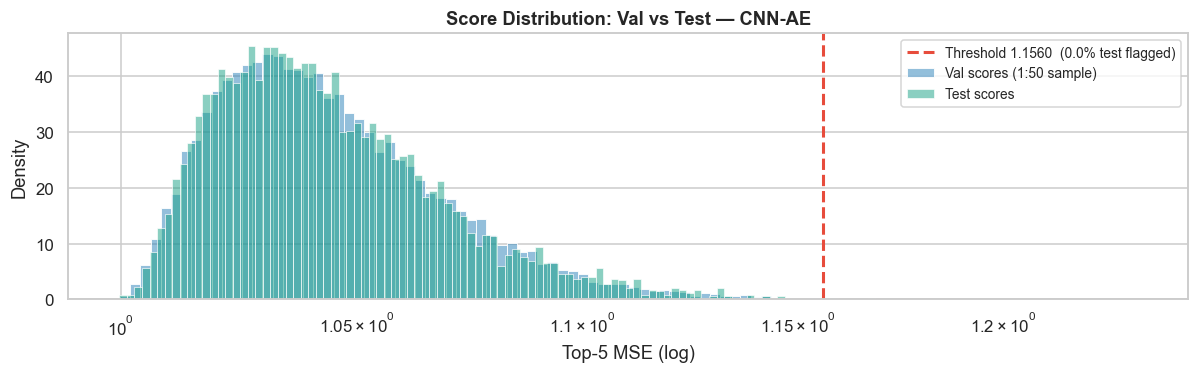

In [14]:
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.histplot(val_scores[::50], bins=100, ax=ax, color=NOMINAL_COLOR, alpha=0.5,
             stat='density', log_scale=(True, False), kde=False,
             label='Val scores (1:50 sample)')
sns.histplot(test_scores, bins=100, ax=ax, color='#16a085', alpha=0.5,
             stat='density', log_scale=(True, False), kde=False,
             label='Test scores')
ax.axvline(BEST_THR, color=ANOMALY_COLOR, lw=2, ls='--',
           label=f'Threshold {BEST_THR:.4f}  ({pct_flagged:.1f}% test flagged)')
ax.set_xlabel(f'Top-{TOPK} MSE (log)'); ax.set_ylabel('Density')
ax.set_title('Score Distribution: Val vs Test — CNN-AE', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()


---
## Timeline — Val + Test

Standardized two-panel plot via `plot_timeline(scores, y_true, threshold, ..., log_y=True)`. Use `index` to switch the x-axis from split-local positions (default) to absolute dataset indices.

In [ ]:
from sentinel.ml_logic.viz import plot_timeline

MODEL_NAME = 'CNN-AE (NB13)'

_ = plot_timeline(val_scores, y_val, BEST_THR,
                  f'{MODEL_NAME} — Val Timeline (log-y) (Kaggle test — unlabeled)', log_y=True)
plt.show(); plt.close()

_ = plot_timeline(test_scores, np.zeros(len(test_scores), dtype=np.int8), BEST_THR,
                  f'{MODEL_NAME} — Test Timeline (log-y) (Kaggle test — unlabeled)', log_y=True)
plt.show(); plt.close()

---
## Submission & Save model

Nach dem Review der Ergebnisse oben die gewünschten Blöcke auskommentieren und ausführen.

In [ ]:
# ── Save model ──────────────────────────────────────────────────────────
# import time
# ts = time.strftime('%Y%m%d_%H%M%S')
# MODEL_PATH = MODELS_DIR / f'cnn_ae_nb13_{ts}.keras'
# model.save(MODEL_PATH)
# print(f'Model saved → {MODEL_PATH}')


In [ ]:
# Save scores — nach Review auskommentieren und ausführen
# SCORES_DIR = PROCESSED_DIR / 'scores'
# SCORES_DIR.mkdir(parents=True, exist_ok=True)
# np.save(SCORES_DIR / 'scores_val_cnn_ae_nb13.npy',  val_scores)
# np.save(SCORES_DIR / 'scores_test_cnn_ae_nb13.npy', test_scores)
# print(f'Scores saved → {SCORES_DIR}/scores_{{val,test}}_cnn_ae_nb13.npy')


In [ ]:
# ── Kaggle submission ───────────────────────────────────────────────────
# submission = pd.DataFrame({'id': test_ids, 'is_anomaly': y_pred_test})
#
# sample_sub = pd.read_parquet('../data/raw/sample_submission.parquet')
# assert list(submission['id']) == list(sample_sub['id']), 'ID mismatch vs sample submission!'
# print('ID alignment: ✓')
#
# ts = time.strftime('%Y%m%d_%H%M%S')
# submission_path = SUBMISSIONS_DIR / f'cnn_ae_nb13_{ts}.parquet'
# submission.to_parquet(submission_path, index=False)
# print(f'Submission saved → {submission_path}')
# print(submission.head())
# print(f'Anomaly rows: {submission["is_anomaly"].sum():,} ({submission["is_anomaly"].mean()*100:.2f}%)')
#
